# INFO 5613 – Class 23: Bipartite networks

[Brian C. Keegan, Ph.D.](http://brianckeegan.com/)  
[Assistant Professor, Department of Information Science](https://www.colorado.edu/cmci/people/information-science/brian-c-keegan)  
University of Colorado Boulder  

Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Import libraries

In [1]:
# Load networkx for working with network data
import networkx as nx

# Load numpy for working with numerical data
import numpy as np

# Load pandas for working with tabular data
import pandas as pd

# Load visualization libraries
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# Load libraries
import scipy.stats as stats
from collections import Counter

# Define a formatting string we can use to print the number of nodes and edges
node_edge_s = "There are {0:,} nodes and {1:,} edges in the network."

## `wikifunctions` and Wikipedia collaborations

[`wikifunctions`](https://github.com/brianckeegan/wikifunctions/) is a collection of Python scripts I've developed for retrieving data from the MediaWiki API. MediaWiki is the software that powers Wikipedia as well as other popular wikis like the Fandom platform. You should have the wikifunctions.py file in the same directory as this notebook for this to work.

In [2]:
import wikifunctions as wf

Get the neighbors linked from the [University of Colorado Boulder](https://en.wikipedia.org/wiki/University_of_Colorado_Boulder) article using the `get_page_outlinks` function.

In [3]:
cub_neighbors = wf.get_page_outlinks('University of Colorado Boulder')
cub_neighbors[:5]

['Public university',
 'Research university',
 'Boulder, Colorado',
 'Colorado',
 'Federated state']

Get the revision history for each one of these articles.

In [4]:
# Remove duplicates
cub_neighbors_set = list(set(cub_neighbors))

# Add CU Boulder to the set of articles
cub_neighbors_set.append('University of Colorado Boulder')

# How many unique articles
len(cub_neighbors_set)

231

What does the revision history for a single article look like? (Adapted from [official documentation](https://www.mediawiki.org/wiki/API:Revisions))

* `revid` - unique ID for this version of the article (unique across all articles)
* `parentid` - the previous versionof the article
* `user` - the name of the user making the change
* `userid` - the ID for the user making the change
* `timestamp` - when the revision was made
* `size` - the size of the article (in bytes) with this change
* `sha1` - a 40-digit [hash](https://en.wikipedia.org/wiki/SHA-1) of the page content, used for comparing if two revisions are identical
* `comment` - revision comment left by editor, sometimes helpful context on what/why change is made
* `anon` - True if the editor is unregistered
* `sha1hidden` - True if the revision has been removed (copyright, abuse, etc.)
* `date` - date extracted from `timestamp`
* `diff` - difference in size between previous and current revisions
* `lag` - difference in time (seconds) between previous and current revisions
* `age` - difference in time (days) between first and current revision

In [5]:
_revs_df = wf.get_all_page_revisions('University of Colorado Boulder')
_revs_df.head()

,revid,parentid,user,userid,timestamp,size,sha1,comment,anon,sha1hidden,commenthidden,page,date,diff,lag,age
0,1320281,0,Dino,13774,2003-08-05 16:42:10+00:00,1037,667d6618a9f7f2c513fa8d023113873d2a2e33ec,Fairly basic stub article on the University of...,NaN,NaN,NaN,University of Colorado Boulder,2003-08-05,NaN,NaN,0.000000
1,2027330,1320281,Dino,13774,2003-08-20 20:03:52+00:00,1171,3cac252055921e94e1ebdccd27e3109906ecb918,"Wow, dude, like the U of Colorado is the party...",NaN,NaN,NaN,University of Colorado Boulder,2003-08-20,134.0,1308102.0,15.140069
2,2159016,2027330,Dale Arnett,25667,2003-12-23 07:08:15+00:00,1232,b4ead31292c677d8d93111992875a0a9b56271cd,,NaN,NaN,NaN,University of Colorado Boulder,2003-12-23,61.0,10753463.0,139.601447
3,2633803,2159016,Dino,13774,2004-01-15 14:07:06+00:00,1236,ecf1d3cd30762f7b82af4fd102681561da274fd4,link added,NaN,NaN,NaN,University of Colorado Boulder,2004-01-15,4.0,2012331.0,162.892315
4,2633812,2633803,Dale Arnett,25667,2004-03-05 03:58:47+00:00,1764,fb49b40d5205445ff2dbf06d24c52e1621e93139,,NaN,NaN,NaN,University of Colorado Boulder,2004-03-05,528.0,4283501.0,212.469873


Read in the CSV file containing the data for the 231 articles.

In [6]:
revs_df = pd.read_csv('neighbor_revs_cuboulder.csv',parse_dates=['timestamp','date'])

# Basic stats
rev_count = len(revs_df)
article_count = len(revs_df['page'].unique())
user_count = len(revs_df['user'].unique())
print("There are {0:,} revisions from {1:,} users to {2:,} articles".format(rev_count,user_count,article_count))

# Inspect
revs_df.head()

/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_73783/515257357.py:1: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  revs_df = pd.read_csv('neighbor_revs_cuboulder.csv',parse_dates=['timestamp','date'])


There are 177,166 revisions from 53,873 users to 228 articles


,revid,parentid,user,anon,userid,timestamp,size,sha1,comment,page,date,diff,lag,age,sha1hidden,commenthidden,userhidden,suppressed
0,476367232,466209262,78.240.181.64,True,0,2012-02-12 00:22:03+00:00,10710,1f6d11e35faaaeecce309a3b0c335390689e6f59,NaN,Mountain bike trials,2012-02-12,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
1,476887766,476367232,Mattyweeks,NaN,16294891,2012-02-14 20:04:12+00:00,10780,d0c2341b118df2453dad3a298fef3119fe556239,/* External links */,Mountain bike trials,2012-02-14,70.0,243729.0,2.820937,NaN,NaN,NaN,NaN
2,479042788,476887766,Kijer,NaN,11000411,2012-02-27 00:44:34+00:00,10727,7230b6261083df5f1955f91fd21f1e35a73aee3d,dead link,Mountain bike trials,2012-02-27,-53.0,1053622.0,15.015637,NaN,NaN,NaN,NaN
3,504113451,479042788,41.240.103.26,True,0,2012-07-25 13:49:44+00:00,10804,c94325e442f3a60c3e621ad6882ab81ffe190d6a,/* External links */,Mountain bike trials,2012-07-25,77.0,12920710.0,164.560891,NaN,NaN,NaN,NaN
4,504260634,504113451,Berean Hunter,NaN,6028820,2012-07-26 12:33:08+00:00,10727,7230b6261083df5f1955f91fd21f1e35a73aee3d,Reverted 1 edit by [[Special:Contributions/41....,Mountain bike trials,2012-07-26,-77.0,81804.0,165.507697,NaN,NaN,NaN,NaN


Exploratory counts.

In [7]:
revs_df['page'].value_counts().head(10)

The Rolling Stones                    6416
Republican Party (United States)      5106
World War II                          4919
Colorado                              4163
Big Ten Conference                    4129
Jazz                                  3727
The Who                               3638
Supreme Court of the United States    3502
Indian Americans                      3164
Esports                               2946
Name: page, dtype: int64

In [8]:
revs_df['user'].value_counts().head(10)

ClueBot NG            3338
Dale Arnett           2155
AnomieBOT             1077
InternetArchiveBot    1009
Citation bot           970
Buaidh                 859
UW Dawgs               854
Ritchie333             820
ElKevbo                724
Monkbot                575
Name: user, dtype: int64

Time series plots.

Text(0.5, 0, '')

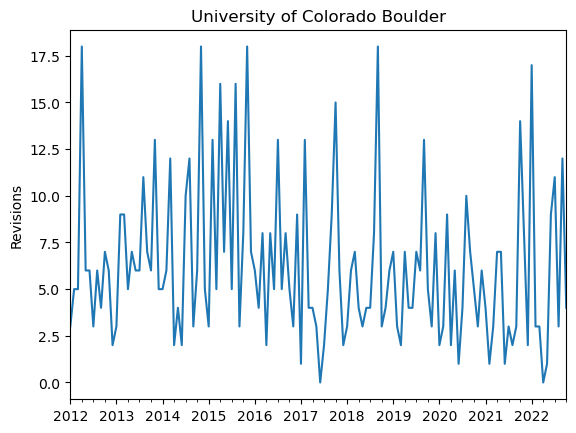

In [12]:
cub_revs_df = revs_df[revs_df['page'] == 'University of Colorado Boulder']

cub_daily_revs = cub_revs_df.groupby(pd.Grouper(key='timestamp',freq='m')).agg({'sha1':'nunique'})['sha1']

ax = cub_daily_revs.plot()
ax.set_title('University of Colorado Boulder')
ax.set_ylabel('Revisions')
ax.set_xlabel(None)

## Make a bipartitle graph

Count the total number of revisions from a user to an article. This is our bipartite edgelist.

In [13]:
# Group the revision DataFrame by user and page and aggregate on the number of unique revisions
rev_el_df = revs_df.groupby(['user','page']).agg({'revid':'nunique'})['revid']

# Turn the index into columns
rev_el_df = rev_el_df.reset_index()

# Rename the columns
rev_el_df.columns = ['user','page','revisions']

rev_el_df.head(10)

,user,page,revisions
0,!dea4u,Kalpana Chawla,2
1,!dea4u,Rugby union,1
2,!dea4u,Science,1
3,$idhu,Distance education,2
4,$uperFan32,Grateful Dead,1
5,(00perMoore,Swimming (sport),1
6,--R-C-R-J--,Theatre,2
7,-5-,Pearl Jam,2
8,-8741Mohsen-10712,Turing Award,1
9,-Alabama-,Bose–Einstein condensate,1


Convert the edgelist into to a networkx Graph object.

In [14]:
rev_g = nx.from_pandas_edgelist(
    df = rev_el_df,
    source = 'user',
    target = 'page',
    edge_attr = ['revisions'],
    create_using = nx.DiGraph
)

print(
    node_edge_s.format(
        rev_g.number_of_nodes(),
        rev_g.number_of_edges()
    )
)

There are 54,098 nodes and 75,941 edges in the network.


### Cleaning up self-loops
One of the most frustrating parts about using Wikipedia data to illustrate bipartite graphs: some users have the same name as articles.

In [15]:
rev_el_df[rev_el_df['user'] == rev_el_df['page']]

,user,page,revisions
34623,Alpha Chi Omega,Alpha Chi Omega,1


If we run a test to ensure that there are two distinct sets of nodes, we get the result `False` because of these self-dealing users.

In [16]:
nx.bipartite.is_bipartite(rev_g)

False

The `from_pandas_edgelist` function didn't create separate nodes for the user "Alpha Chi Omega" and the page "Alpha Chi Omega" but a single node that edited itself, thus breaking the bipartite definition.

In [17]:
list(nx.selfloop_edges(rev_g))

[('Alpha Chi Omega', 'Alpha Chi Omega')]

The best way to handle this is to pre-pend a string to the names of the users and pages to enforce a difference.

In [18]:
rev_el_df['user'] = 'User:'+rev_el_df['user']
rev_el_df['page'] = 'Page:'+rev_el_df['page']

rev_el_df.tail(10)

,user,page,revisions
75931,User:老陳,Page:David J. Wineland,1
75932,User:船到桥头自然沉,Page:Music,1
75933,User:阿文,Page:X Games,1
75934,User:阿道,Page:Memorial,6
75935,User:백돌,Page:Music,2
75936,User:이형주,Page:Proclamation,1
75937,User:총괄자,Page:Republican Party (United States),1
75938,User:태현 정,Page:Ramones,1
75939,User:한민족,Page:Education,1
75940,User:한민족,Page:Kalpana Chawla,2


Re-run the graph construction. Notice the subtle but important change in the number of nodes from before!

In [19]:
# Construct the network
rev_g = nx.from_pandas_edgelist(
    df = rev_el_df,
    source = 'user',
    target = 'page',
    edge_attr = ['revisions'],
    create_using = nx.Graph
)

# Add node attributes
for n,d in rev_g.nodes(data=True):
    if 'User:' in n:
        d['nodetype'] = 'User'
    elif 'Page:' in n:
        d['nodetype'] = 'Page'

# Print out stats
print(
    node_edge_s.format(
        rev_g.number_of_nodes(),
        rev_g.number_of_edges()
    )
)

There are 54,100 nodes and 75,941 edges in the network.


Check if the graph is bipartite again.

In [20]:
nx.bipartite.is_bipartite(rev_g)

True

For some of the analyses we do below, we need to define all the unique users and pages.

In [21]:
rev_g_users = rev_el_df['user'].unique()
rev_g_pages = rev_el_df['page'].unique()

Check to make sure these node sets are bipartitions.

In [22]:
nx.bipartite.is_bipartite_node_set(rev_g,rev_g_users)

True

In [23]:
nx.bipartite.is_bipartite_node_set(rev_g,rev_g_pages)

True

Write the network to disk to visualize in Gephi.

In [24]:
nx.write_gexf(rev_g,'neighbor_revs_cuboulder.gexf')

## Analyzing the network

The methods and algorithms for analyzing unipartite (one-mode) networks do not always generalize to analyzing bipartite (two-mode) networks. The key difference is bipartite networks have a different number of possible edges and neighbors than unipartite networks: edges can only exist from one nodeset to the other nodeset.

### Density

The off-the-shelf `density` function sees a Graph object and proceeds to compute the number of observed edges divided by the number of possible edges. It doesn't know this is a bipartite graph and that some kinds of possible edges are not actually possible, so it reports a very low density.

In [25]:
nx.density(rev_g)

5.1894317527471284e-05

If we use density functions specific to a bipartite graph, we get a much higher density. For many bipartite functions, we need to pass one set of nodes.

Because so many types of ties are not possible, we end up with a much higher density. Note that the density is identitcal regardless of the node set we use.

In [26]:
nx.bipartite.density(rev_g, nodes = rev_g_users)

0.006182702728755361

In [27]:
nx.bipartite.density(rev_g, nodes = rev_g_pages)

0.006182702728755361

### Centrality

The way that networkx computes degree centrality is the fraction of other possible nodes that a node is connected to. 

If we compute the default degree centrality for a page like the "University of Colorado Boulder" we get a slightly different value than the bipartite degree centrality.

In [28]:
nx.degree_centrality(rev_g)['Page:University of Colorado Boulder']

0.009242315015064973

In [29]:
nx.bipartite.degree_centrality(rev_g, rev_g_pages)['Page:University of Colorado Boulder']

0.00928125928125928

We get very different degree centralities for the default versus bipartite degree centrality for a user like "Madcoverboy" (myself).

In [30]:
nx.degree_centrality(rev_g)['User:Madcoverboy']

5.5453890090389834e-05

In [31]:
nx.bipartite.degree_centrality(rev_g, rev_g_pages)['User:Madcoverboy']

0.013157894736842105

### Degree distributions

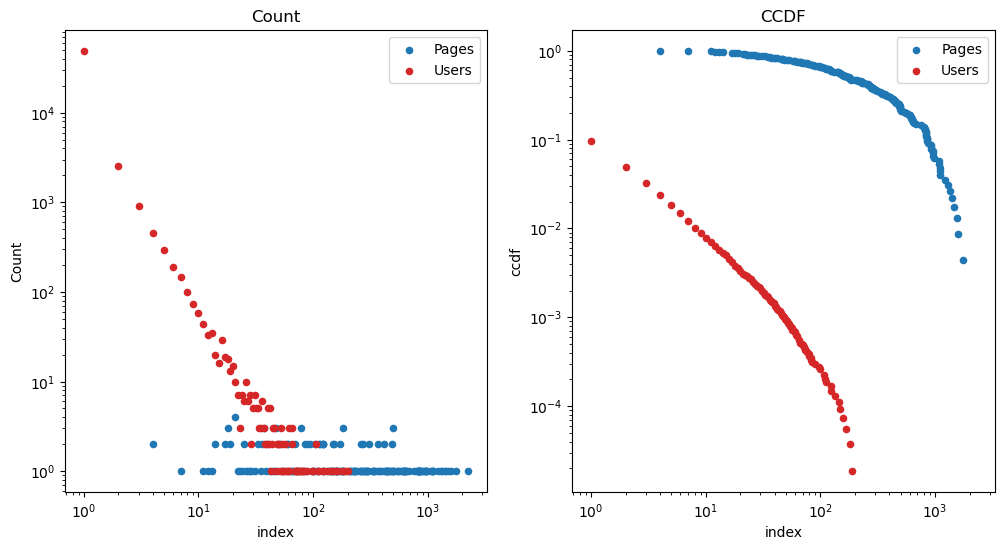

In [32]:
# Compute degrees
rev_g_degree = dict(rev_g.degree())
rev_g_degree_pages = {p:rev_g_degree[p] for p in rev_g_pages}
rev_g_degree_users = {u:rev_g_degree[u] for u in rev_g_users}

# Count the degree
pages_dc_counts = pd.Series(rev_g_degree_pages.values(),name='Count').value_counts()
users_dc_counts = pd.Series(rev_g_degree_users.values(),name='Count').value_counts()

# Clean up
pages_dc_counts = pages_dc_counts.reset_index().sort_values('index',ascending=True)
users_dc_counts = users_dc_counts.reset_index().sort_values('index',ascending=True)

# Compute complementary cumulative degree frequencies
pages_dc_counts['ccdf'] = 1 - pages_dc_counts['Count'].cumsum()/pages_dc_counts['Count'].sum()
users_dc_counts['ccdf'] = 1 - users_dc_counts['Count'].cumsum()/users_dc_counts['Count'].sum()

# Set up figure with two axes on log scales
f,axs = plt.subplots(1,2,figsize=(12,6),subplot_kw={'xscale':'log','yscale':'log'})

# Plot pages count degree distribution
pages_dc_counts.plot.scatter(
    x = 'index', 
    y = 'Count',
    ax = axs[0],
    c = 'tab:blue',
    label = 'Pages'
)

# Plot users count degree distribution
users_dc_counts.plot.scatter(
    x = 'index', 
    y = 'Count',
    ax = axs[0],
    c = 'tab:red',
    label = 'Users',
    title = 'Count'
)

# Plot pages CCDF
pages_dc_counts.plot.scatter(
    x = 'index', 
    y = 'ccdf',
    ax = axs[1],
    label = 'Pages',
    c = 'tab:blue'
)

# Plot users CCDF
users_dc_counts.plot.scatter(
    x = 'index', 
    y = 'ccdf',
    ax = axs[1],
    c = 'tab:red',
    label = 'Users',
    title = 'CCDF'
)

axs[0].legend(loc='upper right')

We will get into this more next week, but the distribution of users' revision frequencies also follows long-tailed distributions.

(1e-06, 1.0)

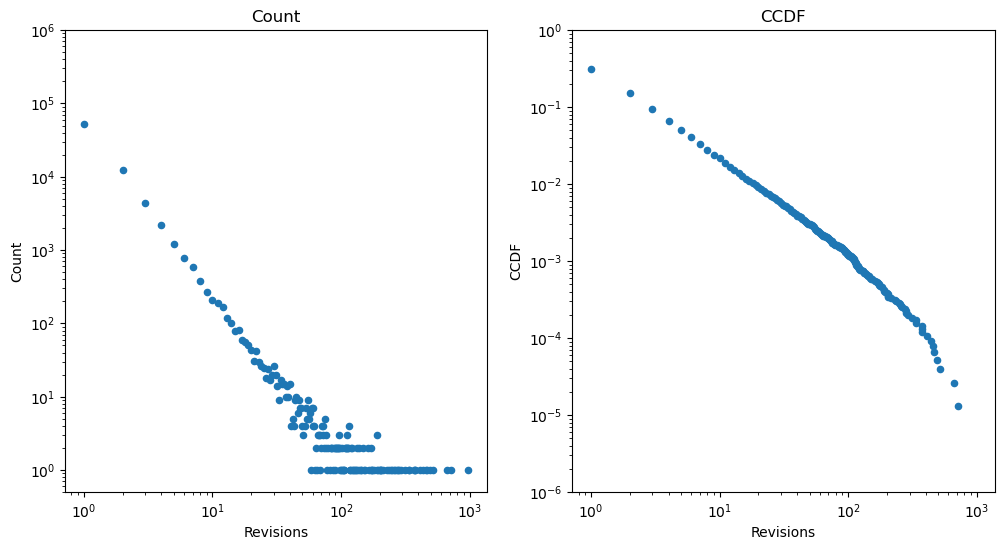

In [33]:
rev_counts = rev_el_df['revisions'].value_counts().sort_index().reset_index()
rev_counts['ccdf'] = 1 - rev_counts['revisions'].cumsum()/rev_counts['revisions'].sum()

# Set up figure with two axes on log scales
f,axs = plt.subplots(1,2,figsize=(12,6),subplot_kw={'xscale':'log','yscale':'log'})

# Plot pages count degree distribution
rev_counts.plot.scatter(
    x = 'index', 
    y = 'revisions',
    ax = axs[0],
    c = 'tab:blue',
    title = 'Count'
)

# Plot users count degree distribution
rev_counts.plot.scatter(
    x = 'index', 
    y = 'ccdf',
    ax = axs[1],
    c = 'tab:blue',
    title = 'CCDF'
)

axs[0].set_xlabel('Revisions')
axs[0].set_ylabel('Count')
axs[0].set_ylim((5e-1,1e6))

axs[1].set_xlabel('Revisions')
axs[1].set_ylabel('CCDF')
axs[1].set_ylim((1e-6,1e0))

### Clustering

The same story holds for clustering as for density and degree.

In [34]:
# This actually takes a minute or two to estimate
nx.average_clustering(rev_g)

0.0

In [35]:
nx.bipartite.average_clustering(rev_g, rev_g_pages)

0.022758272577080404

There are several different ways to calculate clustering in a bipartite network. These all capture the tendency for pages to share editors in common: values closer to 0 imply that an article's editors have contributed to few articles in common and values closer to 1 imply that an article's editors share all articles in common. This definition can be expanded to account for the size of different networks' 

* **Dot** is the intersection of nodes divided by the union of nodes across all the node's neighbors.
* **Min** is the intersection of nodes divided by the smallest set of nodes across all the node's neighbors.
* **Max** is the intersection of nodes divided by the largest set of nodes across all the node's neighbors.

Figure 5 in Latapy, Magnien, & Del Vecchio (2008) provides another visualization:

![bipartite_clustering](http://i.imgur.com/MnLoO9Z.png)

Compute these different types of clustering and compare the results.

In [36]:
pd.Series(nx.bipartite.clustering(rev_g, rev_g_pages, mode='dot')).sort_values(ascending=False).head(10)

Page:Conference on World Affairs    0.037522
Page:Quantitative genetics          0.034750
Page:Monty Miranda                  0.033940
Page:Alpha Chi Omega                0.033628
Page:Bicycle commuting              0.033375
Page:Robert T. Craig                0.033331
Page:Condé Nast Traveler            0.033271
Page:John L. Hall                   0.033258
Page:Solar Decathlon                0.032807
Page:Colorado Buffaloes             0.032488
dtype: float64

In [37]:
pd.Series(nx.bipartite.clustering(rev_g, rev_g_pages, mode='min')).sort_values(ascending=False).head(10)

Page:John Stenner                                                  0.614929
Page:Monty Miranda                                                 0.309888
Page:Harvest project                                               0.292277
Page:Junius Henderson                                              0.269547
Page:CU Independent                                                0.264025
Page:University of Colorado Boulder Computer Science Department    0.258333
Page:Fiske Planetarium                                             0.249403
Page:Boulder Philharmonic Orchestra                                0.231135
Page:University of Colorado Museum of Natural History              0.219271
Page:Robert T. Craig                                               0.217859
dtype: float64

In [38]:
pd.Series(nx.bipartite.clustering(rev_g, rev_g_pages, mode='max')).sort_values(ascending=False).head(10)

Page:Conference on World Affairs    0.050477
Page:Alpha Chi Omega                0.048346
Page:Quantitative genetics          0.048283
Page:Colorado Buffaloes             0.046274
Page:Cañon City, Colorado           0.045980
Page:Condé Nast Traveler            0.045479
Page:Bicycle commuting              0.045347
Page:Golden, Colorado               0.045345
Page:Wiley Rutledge                 0.045078
Page:John L. Hall                   0.045045
dtype: float64

## Random graph models

We can generate random graphs with similar network properties (size, density, degree sequence, *etc*.) and compare the features to our Wikipedia collaboration network.

Random graph.

In [ ]:
bp_er = nx.bipartite.random_graph(
    n = len(rev_g_users),
    m = len(rev_g_pages),
    p = nx.bipartite.density(rev_g,rev_g_users)
)

In [ ]:
# Compute the nodesets for the random graph
bp_er_bot = [n for n,d in bp_er.nodes(data=True) if d['bipartite'] == 0]
bp_er_top = [n for n,d in bp_er.nodes(data=True) if d['bipartite'] == 1]

print("There are {0:,} nodes in the bottom set and {1:,} nodes in the top set.".format(len(bp_er_bot),len(bp_er_top)))

In [ ]:
nx.bipartite.average_clustering(bp_er,bp_er_top)

In [ ]:
def deg_dist_plot(g,top_nodeset,bot_nodeset):
    
    # Compute degrees
    degrees = dict(g.degree())
    degrees_top = {t:degrees[t] for t in top_nodeset}
    degrees_bot = {b:degrees[b] for b in bot_nodeset}

    # Count the degree
    top_counts = pd.Series(degrees_top.values(),name='Count').value_counts()
    bot_counts = pd.Series(degrees_bot.values(),name='Count').value_counts()

    # Clean up
    top_counts = top_counts.reset_index().sort_values('index',ascending=True)
    bot_counts = bot_counts.reset_index().sort_values('index',ascending=True)

    # Compute complementary cumulative degree frequencies
    top_counts['ccdf'] = 1 - top_counts['Count'].cumsum()/top_counts['Count'].sum()
    bot_counts['ccdf'] = 1 - bot_counts['Count'].cumsum()/bot_counts['Count'].sum()

    # Set up figure with two axes on log scales
    f,axs = plt.subplots(1,2,figsize=(12,6),subplot_kw={'xscale':'log','yscale':'log'})

    # Plot pages count degree distribution
    top_counts.plot.scatter(
        x = 'index', 
        y = 'Count',
        ax = axs[0],
        c = 'tab:blue'
    )

    # Plot users count degree distribution
    bot_counts.plot.scatter(
        x = 'index', 
        y = 'Count',
        ax = axs[0],
        c = 'tab:red',
        title = 'Count'
    )

    # Plot pages CCDF
    top_counts.plot.scatter(
        x = 'index', 
        y = 'ccdf',
        ax = axs[1],
        c = 'tab:blue'
    )

    # Plot users CCDF
    bot_counts.plot.scatter(
        x = 'index', 
        y = 'ccdf',
        ax = axs[1],
        c = 'tab:red',
        title = 'CCDF'
    )

In [ ]:
deg_dist_plot(bp_er,bp_er_top,bp_er_bot)

Configuration model (similar degree sequences).

In [ ]:
bp_cm = nx.bipartite.configuration_model(
    aseq = list(rev_g_degree_pages.values()),
    bseq = list(rev_g_degree_users.values())
)

In [ ]:
# Compute the nodesets for the random graph
bp_cm_bot = [n for n,d in bp_cm.nodes(data=True) if d['bipartite'] == 0]
bp_cm_top = [n for n,d in bp_cm.nodes(data=True) if d['bipartite'] == 1]

print("There are {0:,} nodes in the bottom set and {1:,} nodes in the top set.".format(len(bp_cm_bot),len(bp_cm_top)))

In [ ]:
nx.bipartite.average_clustering(bp_cm,bp_cm_bot)

In [ ]:
deg_dist_plot(bp_cm,bp_cm_bot,bp_cm_top)

## Dynamics

Explore the properties of the network year-to-year.

First make a bipartite edgelist of the revision activity year-by-year.

In [39]:
# Groupby year, user, and page and aggregate to number of revisions
annual_rev_snapshot_el = revs_df.groupby([pd.Grouper(key='timestamp',freq='1Y'),'user','page']).agg({'revid':'nunique'})['revid']

# Reset index
annual_rev_snapshot_el = annual_rev_snapshot_el.reset_index()

# Extract year from grouper timestamp
annual_rev_snapshot_el['timestamp'] = annual_rev_snapshot_el['timestamp'].dt.year

# Rename columns
annual_rev_snapshot_el.columns = ['year','user','page','revisions']

# Add User: and Page: prefixes to ensure bipartiteness
annual_rev_snapshot_el['user'] = 'User:' + annual_rev_snapshot_el['user']
annual_rev_snapshot_el['page'] = 'Page:' + annual_rev_snapshot_el['page']

# Inspect
annual_rev_snapshot_el.head()

,year,user,page,revisions
0,2012,User:026fatih,Page:Engineering,1
1,2012,User:08cairnsa,Page:Rowing (sport),2
2,2012,User:0channell,Page:University of Utah,5
3,2012,User:1.187.175.81,Page:Nobel Prize,1
4,2012,User:1.229.69.25,Page:Nobel Prize,1


Turn each year's edgelist into a bipartite network.

In [40]:
# Empty dictionary to store annual graphs
annual_graph_d = {}

# Loop through years from 2001 to 2022
for year in range(2012,2023):
    
    # Subset the edgelist to only revision relationships in that year
    _df = annual_rev_snapshot_el[annual_rev_snapshot_el['year'] == year]
    
    # Make the graph from the edgelist
    _g = nx.from_pandas_edgelist(
        df = _df,
        source = 'user',
        target = 'page',
        edge_attr = ['revisions'],
        create_using = nx.Graph
    )
    
    # Add node attributes
    for n,d in _g.nodes(data=True):
        if 'User:' in n:
            d['nodetype'] = 'User'
        elif 'Page:' in n:
            d['nodetype'] = 'Page'

    # Write the graph to disk
#     nx.write_gexf(_g,'{0}.gexf'.format(year))
    
    # Store the graph in the dictionary
    annual_graph_d[year] = _g

Compute some statistics for each year's graph.

In [43]:
# Empty dictionary to store statistics
annual_graph_stats = {}

# Loop through years and graphs in the dictionary
for year,g in annual_graph_d.items():
    
    # Create a nested dictionary indexed by year
    annual_graph_stats[year] = {}
    
    # Find the user and pages for this year's graph
    users = [n for n,d in g.nodes(data=True) if d['nodetype'] == "User"]
    pages = [n for n,d in g.nodes(data=True) if d['nodetype'] == "Page"]
    
    # Compute the number of users and pages
    annual_graph_stats[year]['Users'] = len(users)
    annual_graph_stats[year]['Pages'] = len(pages)
    
    # Compute the density
    try:
        annual_graph_stats[year]['Density'] = nx.bipartite.density(g,users)
    except ZeroDivisionError:
        annual_graph_stats[year]['Density'] = 0
        
    # Compute the average clustering
    try:
        annual_graph_stats[year]['Page Clustering'] = nx.bipartite.average_clustering(g,pages)
    except:
        annual_graph_stats[year]['Page Clustering'] = 0
        
    # Compute the fraction of nodes in the largest connected component
    lcc = sorted(nx.components.connected_components(g.to_undirected()),key=len,reverse=True)[0]
    annual_graph_stats[year]['LCC fraction'] = len(lcc)/g.number_of_nodes()
    
    # Compute the clustering coefficient for all pages, extract CU Boulder's value
    pages_clustering = nx.bipartite.clustering(g,pages)
    annual_graph_stats[year]['CUB clustering'] = pages_clustering.get('Page:University of Colorado Boulder',0)
    
    # Compte the degree for all nodes, extract CU Boulder's value
    degree = dict(g.degree())
    annual_graph_stats[year]['CUB degree'] = degree.get('Page:University of Colorado Boulder',0)
    
    # Fraction of users present this year from last year
    if year > 2012:
        last_year_g = annual_graph_d[year - 1]
        last_year_users = [n for n,d in last_year_g.nodes(data=True) if d['nodetype'] == "User"]
        
        annual_graph_stats[year]['Returning users'] = len(set(last_year_users) & set(users))/len(set(last_year_users) | set(users))

In [44]:
# Convert the statistics dictionary to a DataFrame
annual_graph_stats_df = pd.DataFrame(annual_graph_stats).T

# Inspect
annual_graph_stats_df

,Users,Pages,Density,Page Clustering,LCC fraction,CUB clustering,CUB degree,Returning users
2012,8702.0,208.0,0.006152,0.019641,0.998653,0.018230,65.0,NaN
2013,7649.0,211.0,0.006295,0.026786,0.999237,0.022107,65.0,0.055584
2014,6436.0,209.0,0.006346,0.023927,0.993078,0.022144,66.0,0.059182
2015,6222.0,213.0,0.006361,0.028057,0.997203,0.021933,67.0,0.064324
2016,6151.0,218.0,0.006380,0.028627,0.997174,0.028421,53.0,0.064527
2017,5608.0,215.0,0.006477,0.034489,0.996909,0.030811,49.0,0.067254
2018,5422.0,215.0,0.006422,0.028228,0.995565,0.032805,52.0,0.070043
2019,5149.0,216.0,0.006518,0.033900,0.998322,0.028725,44.0,0.072980
2020,4906.0,218.0,0.006571,0.040707,0.998829,0.033106,43.0,0.078284
2021,4479.0,223.0,0.006359,0.037999,0.998086,0.032717,39.0,0.077621


Plot the changes in activity over time.

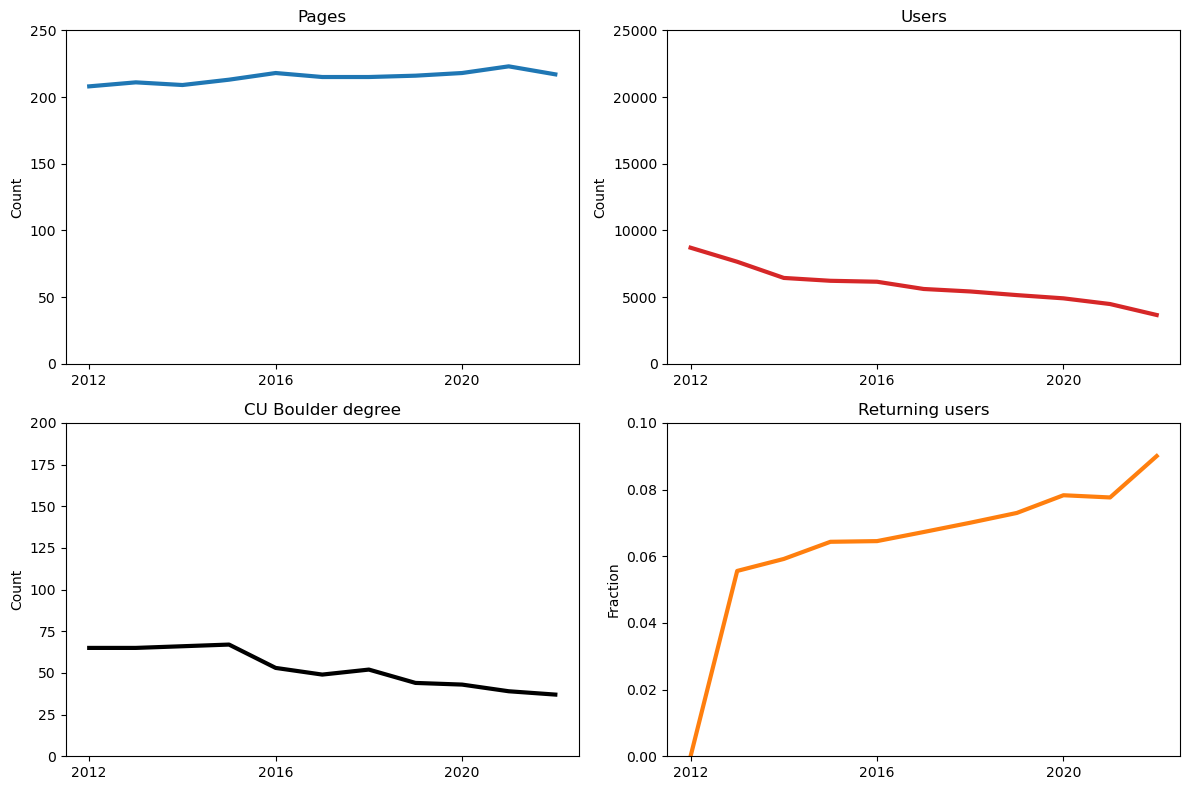

In [45]:
# Set up figure with 3 subplots
f,axs = plt.subplots(2,2,figsize=(12,8),subplot_kw={'xticks':range(2000,2022,4)})

# Populate each subplot
annual_graph_stats_df['Pages'].plot(ax=axs[0,0],c='tab:blue',lw=3)
annual_graph_stats_df['Users'].plot(ax=axs[0,1],c='tab:red',lw=3)
annual_graph_stats_df['CUB degree'].plot(ax=axs[1,0],c='k',lw=3)
annual_graph_stats_df['Returning users'].fillna(0).plot(ax=axs[1,1],c='tab:orange',lw=3)

# Add subplot titles
axs[0,0].set_title('Pages')
axs[0,1].set_title('Users')
axs[1,0].set_title('CU Boulder degree')
axs[1,1].set_title('Returning users')

# Add subplot y axes
axs[0,0].set_ylabel('Count')
axs[0,1].set_ylabel('Count')
axs[1,0].set_ylabel('Count')
axs[1,1].set_ylabel('Fraction')

# Scale subplot y axes
axs[0,0].set_ylim(0,250)
axs[0,1].set_ylim(0,25000)
axs[1,0].set_ylim(0,200)
axs[1,1].set_ylim(0,.1)

f.tight_layout()

Text(0.5, 1.0, 'CU Boulder clustering')

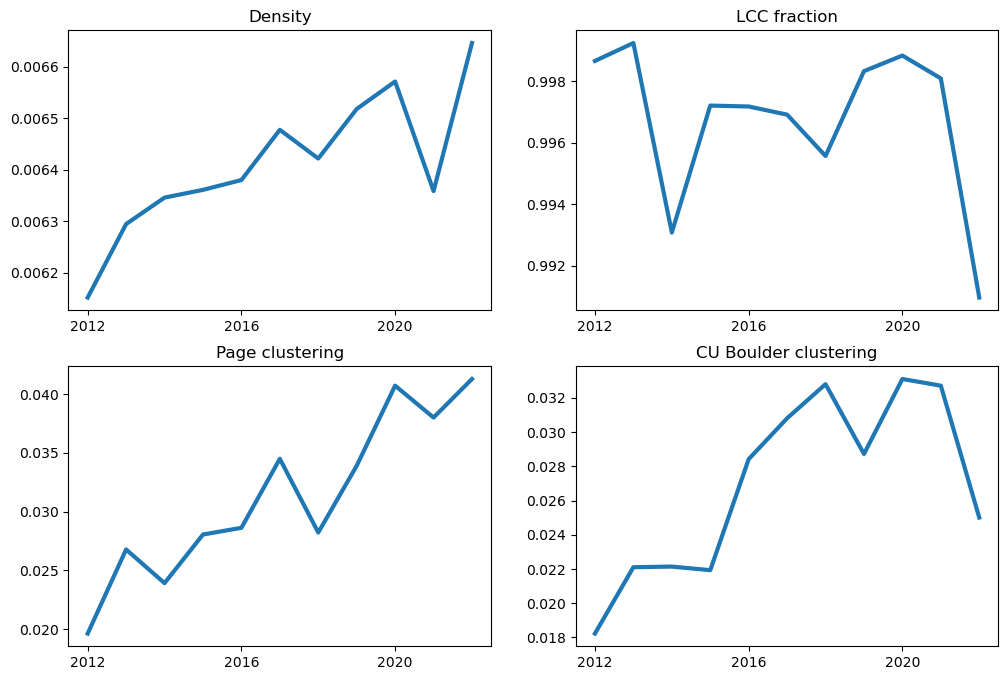

In [46]:
# Set up a figure with 3 subplots
f,axs = plt.subplots(2,2,figsize=(12,8),subplot_kw={'xticks':range(2000,2022,4)})

# Populate each subplot
annual_graph_stats_df['Density'].plot(ax=axs[0,0],lw=3)
annual_graph_stats_df['LCC fraction'].plot(ax=axs[0,1],lw=3)
annual_graph_stats_df['Page Clustering'].plot(ax=axs[1,0],lw=3)
annual_graph_stats_df['CUB clustering'].plot(ax=axs[1,1],lw=3)

# Add subplot titles
axs[0,0].set_title('Density')
axs[0,1].set_title('LCC fraction')
axs[1,0].set_title('Page clustering')
axs[1,1].set_title('CU Boulder clustering')

### Projections

In [47]:
annual_proj_g = {}

for year,g in annual_graph_d.items():
    annual_proj_g[year] = {}
    
    users = [n for n,d in g.nodes(data=True) if d['nodetype'] == "User"]
    pages = [n for n,d in g.nodes(data=True) if d['nodetype'] == "Page"]
    
    annual_proj_g[year]['pages'] = nx.bipartite.weighted_projected_graph(g,pages)
#     annual_proj_g[year]['users'] = nx.bipartite.weighted_projected_graph(g,users)

Visualize one of the annual projected networks.

217 10933 0.46650452295613587


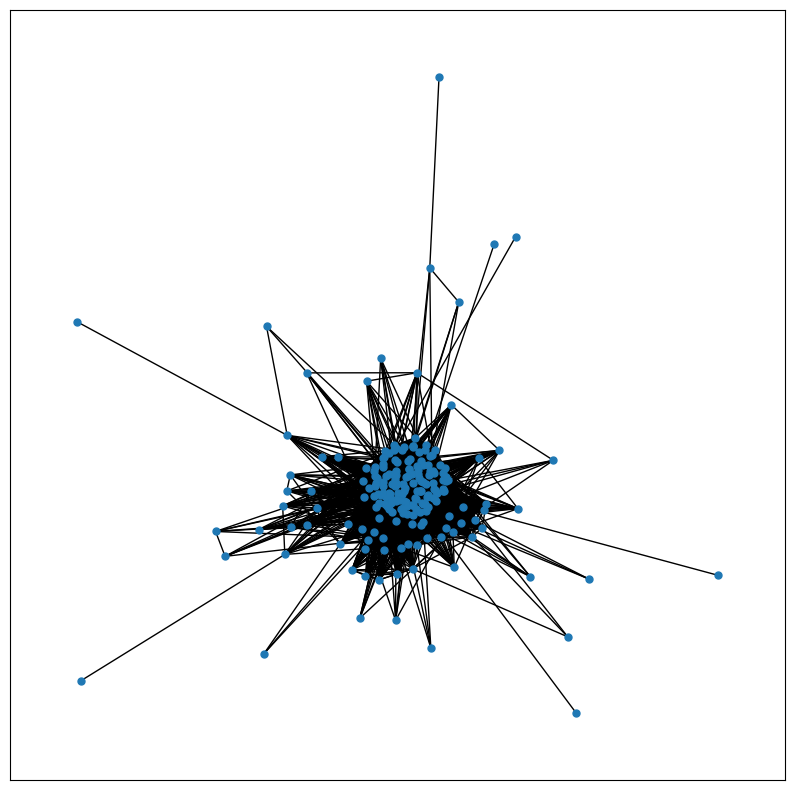

In [51]:
_g = annual_proj_g[2022]['pages']

print(_g.number_of_nodes(), _g.number_of_edges(), nx.density(_g))

lcc = nx.subgraph(
    G = _g,
    nbunch = sorted(nx.components.connected_components(_g),key=len,reverse=True)[0]
)

f,ax = plt.subplots(figsize=(10,10))
nx.draw_networkx(lcc,with_labels=False,node_size=25,ax=ax)

Examine edge weights.

Text(0, 0.5, 'Count')

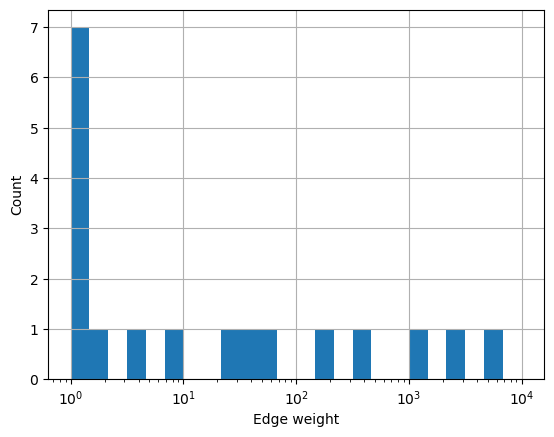

In [52]:
weights = [d['weight'] for i,j,d in _g.edges(data=True)]
weights_count = pd.Series(weights).value_counts()

ax = weights_count.hist(bins=np.logspace(0,4,25))
ax.set_xscale('log')
ax.set_xlabel('Edge weight')
ax.set_ylabel('Count')

Re-visualize network with edge weights filtered above 1.

In [53]:
filtered_edges = [(i,j,d) for i,j,d in _g.edges(data=True) if d['weight'] > 1]
filtered_g = nx.Graph()
filtered_g.add_edges_from(filtered_edges)

print(filtered_g.number_of_nodes(), filtered_g.number_of_edges(), nx.density(filtered_g))

166 4516 0.3297553851770719


In [60]:
filtered_edges = [(i,j,d) for i,j,d in _g.edges(data=True) if d['weight'] > 5]
filtered_g = nx.Graph()
filtered_g.add_edges_from(filtered_edges)

print(filtered_g.number_of_nodes(), filtered_g.number_of_edges(), nx.density(filtered_g))

54 145 0.1013277428371768


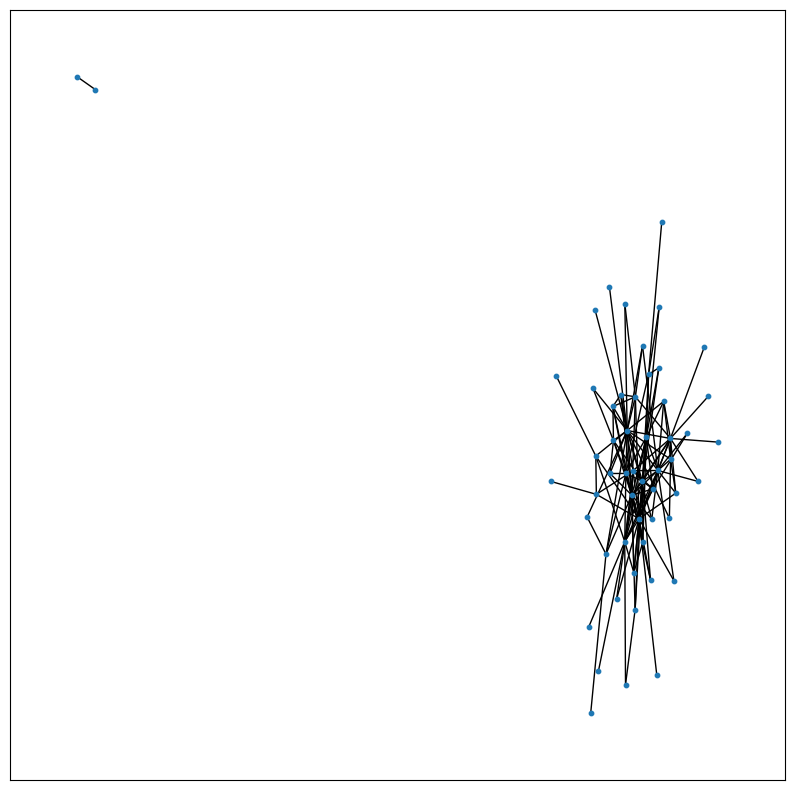

In [61]:
f,ax = plt.subplots(figsize=(10,10))
nx.draw_networkx(filtered_g,with_labels=False,node_size=10,ax=ax)

## IMDB data

In [62]:
import json

In [71]:
with open('imdb_data.json','r') as f:
    imdb_json = f.readlines()
    
imdb_json = [json.loads(i) for i in imdb_json]
imdb_json

[{'rank': 1,
  'movie_name': 'The Shawshank Redemption',
  'movie_year': '1994',
  'genre': ['Drama'],
  'director_name': 'Frank Darabont',
  'rating': '9.3',
  'actors_list': ['Tim Robbins',
   'Morgan Freeman',
   'Bob Gunton',
   'William Sadler',
   'Clancy Brown',
   'Gil Bellows',
   'Mark Rolston',
   'James Whitmore',
   'Jeffrey DeMunn',
   'Larry Brandenburg',
   'Neil Giuntoli',
   'Brian Libby',
   'David Proval',
   'Joseph Ragno',
   'Jude Ciccolella',
   'Paul McCrane',
   'Renee Blaine',
   'Scott Mann']},
 {'rank': 2,
  'movie_name': 'The Godfather',
  'movie_year': '1972',
  'genre': ['Crime', 'Drama'],
  'director_name': 'Francis Ford Coppola',
  'rating': '9.2',
  'actors_list': ['Marlon Brando',
   'Al Pacino',
   'James Caan',
   'Diane Keaton',
   'Richard S. Castellano',
   'Robert Duvall',
   'Sterling Hayden',
   'John Marley',
   'Richard Conte',
   'Al Lettieri',
   'Abe Vigoda',
   'Talia Shire',
   'Gianni Russo',
   'John Cazale',
   'Rudy Bond',
   'Al M

In [78]:
movies_edgelist = []
movies_list = []
actors_list = []

for _movie in imdb_json:
    _movie_name = _movie.get('movie_name')
    
    movies_list.append(_movie_name)
    
    for _actor in _movie.get('actors_list'):
        movies_edgelist.append((_actor,_movie_name))
        actors_list.append(_actor)

In [80]:
imdb_g = nx.Graph()

for (_actor,_movie) in movies_edgelist:
    imdb_g.add_edge(_actor,_movie)
    
for _node in imdb_g.nodes():
    if _node in movies_list:
        imdb_g.nodes[_node]['type'] = 'movie'
    else:
        imdb_g.nodes[_node]['type'] = 'actor'

In [76]:
imdb_g.number_of_nodes(), imdb_g.number_of_edges()

(4083, 4435)

In [82]:
nx.bipartite.is_bipartite(imdb_g)

True

In [83]:
nx.write_gexf(imdb_g,'imdb_top_250.gexf')

In [84]:
movies_g = nx.bipartite.weighted_projected_graph(imdb_g,list(set(movies_list)))

movies_g.number_of_nodes(), movies_g.number_of_edges()

(250, 664)

In [85]:
actors_g = nx.bipartite.weighted_projected_graph(imdb_g,list(set(actors_list)))

actors_g.number_of_nodes(), actors_g.number_of_edges()

(3833, 36791)

In [86]:
nx.write_gexf(movies_g,'imdb_movies_projection.gexf')

In [87]:
nx.write_gexf(actors_g,'imdb_actors_projection.gexf')

## Appendix: Data retrieval
Retrieve the revision history meta-data for all these neighboring articles.

In [ ]:
rev_d = {}

for article in cub_neighbors_set:
    try:
        # Retrieve the page revisions
        _df =  wf.get_page_revisions_from_date(article,start='2012-01-01')
        
        # In case of a redirected title, get the new page title
        _title = _df.loc[0,'page']
        
        # Assign to dictionary
        rev_d[_title] = _df
        
    # Stop scraping on an interrupt instead of going to next article
    except KeyboardInterrupt:
        break
    
    # If there's some other kind of error, print out the article name
    except:
        print("Error on {0}".format(article))
        pass

Concatenate the data together into a giant DataFrame.

In [ ]:
# Concatenate all the DataFrames into a giant DataFrame
revs_df = pd.concat(rev_d.values()).reset_index(drop=True)

# Save to disk
revs_df.to_csv('neighbor_revs_cu_boulder.csv',index=False)

# Basic stats
rev_count = len(revs_df)
article_count = len(revs_df['page'].unique())
user_count = len(revs_df['user'].unique())
print("There are {0:,} revisions from {1:,} users to {2:,} articles".format(rev_count,user_count,article_count))

# Inspect
revs_df.head()